# Brain Tumor Classification: SVM vs. Vision Transformer (ViT)

---
## Step 0 : Import Libraries

This section imports all necessary libraries for data manipulation, visualization, machine learning model building (SVM), and deep learning (ViT).

In [2]:
import warnings
warnings.filterwarnings('ignore')

from tqdm.notebook import tqdm

import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)


import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from datasets import load_dataset          # Hugging Face datasets

from transformers import (
    ViTForImageClassification,
    ViTImageProcessor,
)

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("Libraries imported successfully!")


ModuleNotFoundError: No module named 'matplotlib'

---
## Step 1: Define the problem

**Medical Question:** Can brain MRI images be used to accurately classify the type of brain tumor present in a patient?

**Dataset:** Hemg/Brain-Tumor-MRI-Dataset (available on Hugging Face)

**Source:** Brain MRI scans of patients with different types of brain tumors, along with normal brain MRI scans.
- Each sample: A brain MRI image.
- 4 classes to predict:
Glioma,
Meningioma,
Pituitary Tumor,
No Tumor

ML Setup:

- Input (X): A single grayscale brain MRI image.
- Output (y): One of the four brain MRI class labels (Glioma, Meningioma, Pituitary Tumor, or No Tumor).
- Task type: Multi-class image classification.

In this section, we define the problem statement, the dataset used (Brain-Tumor-MRI-Dataset), the input and output features, and the type of machine learning task (multi-class image classification).

---
##Step 2: Load the dataset and Split

Here, the Brain-Tumor-MRI-Dataset is loaded from Hugging Face and split into training, validation, and testing sets. We also define the class names and observe the class distribution.

In [ ]:
from datasets import load_dataset
from collections import Counter

# Load the dataset
print("Downloading Brain-Tumor-MRI-Dataset from Hugging Face...")
dataset = load_dataset("Hemg/Brain-Tumor-MRI-Dataset")

# Access the predefined splits
train_ds = dataset["train"]

print(f"\nTraining set: {len(train_ds)} images")

print(f"\nColumns : {train_ds.column_names}")
print(f"Features: {train_ds.features}")

# Class definitions for Brain-Tumor-MRI-Dataset
CLASS_NAMES = [
    "glioma_tumor",
    "meningioma_tumor",
    "no_tumor",
    "pituitary_tumor"
]

NUM_CLASSES = len(CLASS_NAMES)

LABEL_MAP = {
    0: "glioma_tumor",
    1: "meningioma_tumor",
    2: "no_tumor",
    3: "pituitary_tumor"
}

# Class distribution in the training set
train_counts = Counter(train_ds["label"])

print("\nTraining set class distribution:")
for lbl in sorted(train_counts):
    print(f"  Label {lbl} — {LABEL_MAP[lbl]:<24}: {train_counts[lbl]:>5} images")

README.md:   0%|          | 0.00/622 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  155MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/7023 [00:00<?, ? examples/s]


Training set: 7023 images

Columns : ['image', 'label']
Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['glioma', 'meningioma', 'notumor', 'pituitary'])}

Training set class distribution:
  Label 0 — glioma_tumor            :  1621 images
  Label 1 — meningioma_tumor        :  1645 images
  Label 2 — no_tumor                :  2000 images
  Label 3 — pituitary_tumor         :  1757 images


In [ ]:
# Split the original training set into 80% for further train/val split and 20% for test
initial_split = dataset["train"].train_test_split(
    test_size=0.20,  # 20% for test_hf
    seed=42,
    stratify_by_column="label"
)

train_val_hf = initial_split["train"] # 80% of original training set
test_hf      = initial_split["test"]  # 20% of original training set

# Split the train_val_hf (80% of original) into 75% for train and 25% for val
# This results in 0.75 * 0.80 = 60% for train_hf and 0.25 * 0.80 = 20% for val_hf
final_split = train_val_hf.train_test_split(
    test_size=0.25,  # 25% of train_val_hf for val_hf
    seed=42,
    stratify_by_column="label"
)

train_hf = final_split["train"]
val_hf   = final_split["test"]

print(f"Train : {len(train_hf):>5} images (60%)")
print(f"Val   : {len(val_hf):>5} images (20%)")
print(f"Test  : {len(test_hf):>5} images (20%)")
print(f"Total : {len(train_hf)+len(val_hf)+len(test_hf):>5} images (100%)")

Train :  4213 images (60%)
Val   :  1405 images (20%)
Test  :  1405 images (20%)
Total :  7023 images (100%)



## Step 4 — Explore the data
### 3.1 One Image per Class

This section performs an initial exploration of the dataset to understand its characteristics, including visualizing example images and checking class distribution.

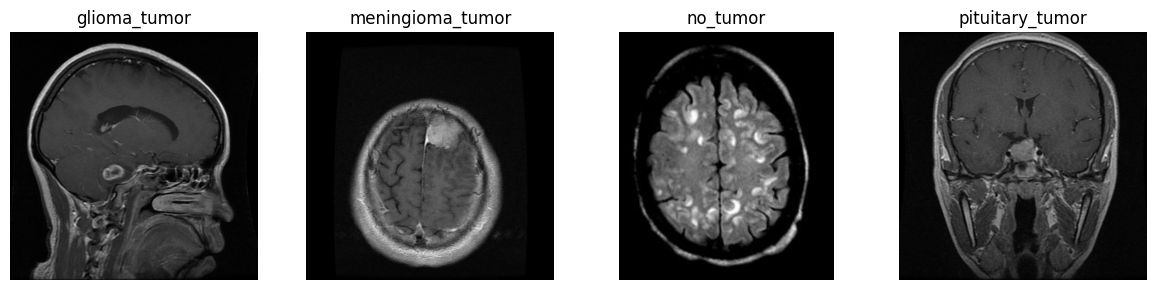

In [ ]:
# Store one example image for each class
examples = {}

# Search through the training dataset to find one image per class
for sample in train_hf:
    label = sample["label"]

    if label not in examples:
        examples[label] = sample["image"]

    # Stop when we have all four classes
    if len(examples) == 4:
        break

# Plot one image per class
plt.figure(figsize=(12, 3))

for i, (label, image) in enumerate(sorted(examples.items())):
    plt.subplot(1, 4, i + 1)

    plt.imshow(image, cmap="gray")
    plt.title(CLASS_NAMES[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

We visualize one example image for each of the four tumor classes to get a qualitative understanding of the data.

### 3.2 Class Distribution (Training Set)

This part displays and plots the distribution of images across the different classes in the training set to check for class imbalance.

Training set class distribution:
glioma_tumor             : 973 images
meningioma_tumor         : 987 images
no_tumor                 : 1200 images
pituitary_tumor          : 1053 images


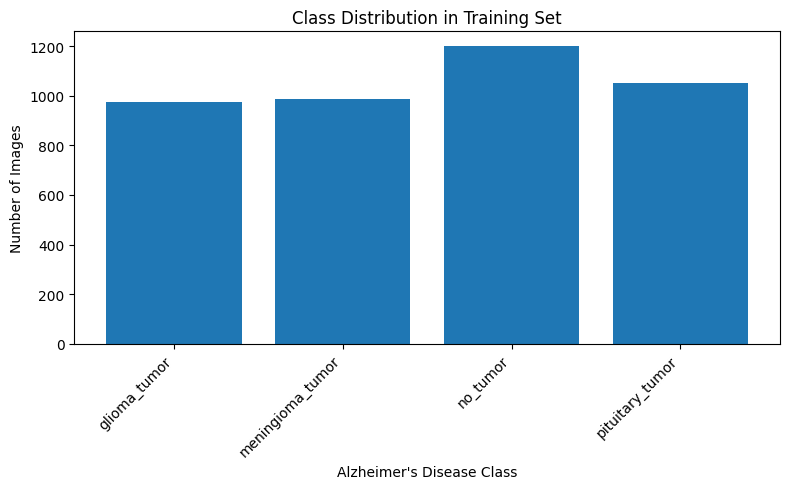

In [ ]:
# Count samples per class
train_counts = Counter(train_hf["label"])

# Prepare labels and values
labels = [CLASS_NAMES[i] for i in sorted(train_counts.keys())]
counts = [train_counts[i] for i in sorted(train_counts.keys())]

# Print class distribution
print("Training set class distribution:")
for label, count in zip(labels, counts):
    print(f"{label:<25}: {count} images")

# Plot distribution
plt.figure(figsize=(8, 5))

plt.bar(labels, counts)

plt.xlabel("Alzheimer's Disease Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution in Training Set")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

---
## Step 4: Train the models (SVM and viT)

This main section focuses on training two different models: a Support Vector Machine (SVM) and a Vision Transformer (ViT), to classify brain tumor images.

---
### 4.1. Support Vector Machines (SVM)

4.1.1. Define image preprocessing

Resize + convert to tensor + normalize pixels

Here, we train a traditional Support Vector Machine (SVM) model for image classification. This involves several preprocessing steps specific to SVMs.

In [ ]:
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

Before feeding images to the SVM, they are resized, converted to grayscale, and transformed into tensors.

4.1.2. Convert images into NumPy arrays

This function converts the preprocessed images into flattened NumPy arrays suitable for SVM input.

In [ ]:
def preprocess_dataset(dataset):

    images = []
    labels = []

    for item in dataset:

        img = item["image"]
        label = item["label"]

        # Resize and normalize
        img = transform(img)

        # Tensor shape:
        # (1,64,64)

        # Convert tensor to numpy
        img = img.numpy()

        # Flatten:
        # (1,64,64) -> (4096,)
        img = img.flatten()

        images.append(img)
        labels.append(label)

    return np.array(images), np.array(labels)

4.1.3. Apply preprocessing

The preprocessing function is applied to the training, validation, and test datasets to convert images into feature arrays.

In [ ]:
X_train, y_train = preprocess_dataset(train_hf)

X_val, y_val = preprocess_dataset(val_hf)

X_test, y_test = preprocess_dataset(test_hf)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(4213, 4096)
(1405, 4096)
(1405, 4096)


4.1.4. Standardize features

Important: fit only on training data.

Features are standardized using `StandardScaler`, fitting only on the training data to prevent data leakage.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

print("Scaling done.")

# Sanity check: Find the first non-constant feature to check its scaling
non_constant_feature_idx = -1
for i in range(X_train.shape[1]):
    if np.std(X_train[:, i]) > 1e-6: # Check if std is not ~zero
        non_constant_feature_idx = i
        break

if non_constant_feature_idx != -1:
    print(f"  Mean of scaled feature {non_constant_feature_idx} (non-constant): {X_train_scaled[:, non_constant_feature_idx].mean():.4f}  (should be ~0)")
    print(f"  Std  of scaled feature {non_constant_feature_idx} (non-constant): {X_train_scaled[:, non_constant_feature_idx].std():.4f}   (should be ~1)")
else:
    print("  Could not find a non-constant feature in X_train to perform specific checks.")

# Overall checks for the entire scaled dataset
print(f"\nOverall mean of X_train_scaled: {X_train_scaled.mean():.4f} (should be ~0)")
print(f"Overall std of X_train_scaled: {X_train_scaled.std():.4f} (should be ~1)")

Scaling done.
  Mean of scaled feature 0 (non-constant): -0.0000  (should be ~0)
  Std  of scaled feature 0 (non-constant): 1.0000   (should be ~1)

Overall mean of X_train_scaled: -0.0000 (should be ~0)
Overall std of X_train_scaled: 1.0000 (should be ~1)


4.1.5.Train SVM with different C values

The SVM model is trained with various `C` values (regularization parameter), and the best performing model is selected based on validation Micro F1 score.

In [ ]:
# Try different values of C (regularization parameter)
c_values = [0.1, 0.25, 0.5, 1, 10, 20, 100]

print("Training SVM with different C values...\n")
print(f"{'C':>6}  {'Val Accuracy':>14}  {'Val Micro F1':>14}")
print("-" * 40)

results = {}

for c in c_values:

    model = SVC(
        C=c,
        kernel="rbf",
        gamma="scale",
        class_weight="balanced",
        random_state=42
    )

    # Train on training set
    model.fit(
        X_train_scaled,
        y_train
    )

    # Validation prediction
    y_pred = model.predict(
        X_val_scaled
    )

    # Evaluation metrics
    val_acc = accuracy_score(
        y_val,
        y_pred
    )

    val_f1 = f1_score(
        y_val,
        y_pred,
        average="micro"
    )

    # Save model and scores
    results[c] = (
        model,
        val_acc,
        val_f1
    )

    print(
        f"C={c:<5}  Val Accuracy = {val_acc*100:.2f}%  "
        f"Val Micro F1 = {val_f1:.3f}"
    )


# Select the best C based on validation accuracy
best_c = max(
    results,
    key=lambda c: results[c][1]
)

best_model = results[best_c][0]
best_val_acc = results[best_c][1]
best_val_f1 = results[best_c][2]


print()
print(
    f"Best C = {best_c}"
)
print(
    f"Validation Accuracy = {best_val_acc*100:.2f}%"
)
print(
    f"Validation Micro F1 = {best_val_f1:.3f}"
)

Training SVM with different C values...

     C    Val Accuracy    Val Micro F1
----------------------------------------
C=0.1    Val Accuracy = 76.16%  Val Micro F1 = 0.762
C=0.25   Val Accuracy = 84.41%  Val Micro F1 = 0.844
C=0.5    Val Accuracy = 87.19%  Val Micro F1 = 0.872
C=1      Val Accuracy = 90.75%  Val Micro F1 = 0.907
C=10     Val Accuracy = 93.74%  Val Micro F1 = 0.937
C=20     Val Accuracy = 94.16%  Val Micro F1 = 0.942
C=100    Val Accuracy = 94.09%  Val Micro F1 = 0.941

Best C = 20
Validation Accuracy = 94.16%
Validation Micro F1 = 0.942


---
### 4.2. Pretrained Vision Transformer (viT)
 4.2.1 — Load the Pretrained ViT and Its Processor

This section details the fine-tuning of a pretrained Vision Transformer (ViT) model for the brain tumor classification task.

In [ ]:
MODEL_NAME = "google/vit-base-patch16-224"

print(f"Loading processor and model from '{MODEL_NAME}' ...")
processor = ViTImageProcessor.from_pretrained(MODEL_NAME)
vit_model = ViTForImageClassification.from_pretrained(MODEL_NAME)

print("\nLoaded successfully!")
print(f"  Patch size      : {processor.size}  px")
print(f"  Image mean      : {processor.image_mean}")
print(f"  Image std       : {processor.image_std}")
print(f"\nClassifier head (original):")
print(f"  {vit_model.classifier}")
print(f"  → Pretrained for 1,000 ImageNet classes")

Loading processor and model from 'google/vit-base-patch16-224' ...


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


Loaded successfully!
  Patch size      : SizeDict(height=224, width=224, longest_edge=None, shortest_edge=None, max_height=None, max_width=None)  px
  Image mean      : (0.5, 0.5, 0.5)
  Image std       : (0.5, 0.5, 0.5)

Classifier head (original):
  Linear(in_features=768, out_features=1000, bias=True)
  → Pretrained for 1,000 ImageNet classes


The pretrained ViT model and its corresponding image processor are loaded from Hugging Face. The original classification head is designed for 1,000 ImageNet classes.

4.2.2 — Dummy Input / Output Demo

A dummy forward pass is performed to demonstrate the input and output shapes of the pretrained ViT model before modification.

In [ ]:
# A random batch of 2 RGB images (224×224 — the size ViT expects)
dummy_batch = torch.randn(2, 3, 224, 224)

vit_model.eval()
with torch.no_grad():
    dummy_out = vit_model(pixel_values=dummy_batch)

print("─" * 50)
print("  ViT — Dummy Forward Pass (pretrained)")
print("─" * 50)
print(f"  Input  shape : {dummy_batch.shape}")
print(f"  Output logits: {dummy_out.logits.shape}   ← 1,000 ImageNet classes")
print()
print("  Classifier layer:")
print(f"    {vit_model.classifier}")
print()
print("  → We need to replace this with nn.Linear(768, 4) for our task.")

──────────────────────────────────────────────────
  ViT — Dummy Forward Pass (pretrained)
──────────────────────────────────────────────────
  Input  shape : torch.Size([2, 3, 224, 224])
  Output logits: torch.Size([2, 1000])   ← 1,000 ImageNet classes

  Classifier layer:
    Linear(in_features=768, out_features=1000, bias=True)

  → We need to replace this with nn.Linear(768, 4) for our task.


4.2.3 — Replace the FC Head with 4 Output Classes

The original classification head of the ViT model is replaced with a new linear layer configured for our 4 output classes.

In [ ]:
hidden_size = vit_model.config.hidden_size   # 768 for ViT-base
vit_model.classifier = nn.Linear(hidden_size, NUM_CLASSES)

print("Classifier replaced:")
print(f"  nn.Linear({hidden_size}, {NUM_CLASSES})  ← {', '.join(CLASS_NAMES)}")
print()
# Verify output shape with the new head
with torch.no_grad():
    new_out = vit_model(pixel_values=dummy_batch)
print(f"New output shape: {new_out.logits.shape}   ✓")

Classifier replaced:
  nn.Linear(768, 4)  ← glioma_tumor, meningioma_tumor, no_tumor, pituitary_tumor

New output shape: torch.Size([2, 4])   ✓


4.2.4— Freeze the Backbone

The backbone layers of the ViT model are frozen, meaning only the newly added classification head will be trained during fine-tuning.

In [ ]:
# Freeze everything
for param in vit_model.parameters():
    param.requires_grad = False

# Unfreeze only the classifier head
for param in vit_model.classifier.parameters():
    param.requires_grad = True

# Count trainable vs frozen parameters
total_params     = sum(p.numel() for p in vit_model.parameters())
trainable_params = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f"Total parameters     : {total_params:>12,}")
print(f"Frozen (backbone)    : {frozen_params:>12,}  ← untouched pretrained weights")
print(f"Trainable (FC head)  : {trainable_params:>12,}  ← only these will be updated")
print()
print("Trainable layers:")
for name, param in vit_model.named_parameters():
    if param.requires_grad:
        print(f"  {name}  {tuple(param.shape)}")

Total parameters     :   85,801,732
Frozen (backbone)    :   85,798,656  ← untouched pretrained weights
Trainable (FC head)  :        3,076  ← only these will be updated

Trainable layers:
  classifier.weight  (4, 768)
  classifier.bias  (4,)


4.2.5— Build the ViT Transform and DataLoaders

Custom `Dataset` and `DataLoader` classes are created to handle image loading and preprocessing for the ViT model, ensuring images are in the correct format (RGB, resized, normalized).

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader # Ensure Dataset and DataLoader are imported

# Define BATCH_SIZE
BATCH_SIZE = 32 # You can adjust this value

class ViTDataset(Dataset):
    def __init__(self, hf_dataset, processor):
        self.hf_dataset = hf_dataset
        self.processor = processor

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        image = item['image']
        label = item['label']

        # Convert grayscale image to RGB format, as ViT models typically expect 3 channels
        if image.mode != 'RGB':
            image = image.convert('RGB')

        # The processor expects a PIL Image or array-like
        # It returns a BatchEncoding with 'pixel_values'
        inputs = self.processor(images=image, return_tensors="pt")
        # Squeeze to remove the batch dimension added by the processor for a single image
        pixel_values = inputs["pixel_values"].squeeze()

        return {"pixel_values": pixel_values, "labels": torch.tensor(label)}

vit_train_ds = ViTDataset(train_hf, processor=processor)
vit_val_ds   = ViTDataset(val_hf,   processor=processor)
vit_test_ds  = ViTDataset(test_hf,  processor=processor)

vit_train_loader = DataLoader(vit_train_ds, batch_size=BATCH_SIZE, shuffle=True)
vit_val_loader   = DataLoader(vit_val_ds,   batch_size=BATCH_SIZE, shuffle=False)
vit_test_loader  = DataLoader(vit_test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"ViT train batches : {len(vit_train_loader)}")
print(f"ViT val   batches : {len(vit_val_loader)}")
print(f"ViT test  batches : {len(vit_test_loader)}")

ViT train batches : 132
ViT val   batches : 44
ViT test  batches : 44


4.2.6— Train Only the FC Head

The ViT model's classification head is fine-tuned using the training data, while monitoring training loss and validation metrics (accuracy and F1 score) over epochs.

In [ ]:
def train_vit_head(model, train_loader, val_loader, epochs=15, lr=1e-3):
    model = model.to("cuda")
    criterion = nn.CrossEntropyLoss()
    # Only pass trainable parameters to the optimizer
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )

    train_losses, val_accs, val_f1_scores = [], [], []

    for epoch in range(epochs):
        # ── Training ──────────────────────────────────────────────────────
        model.train()
        epoch_loss = 0.0
        for batch in (train_bar:= tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [Train]: ")):
            images = batch["pixel_values"].to("cuda")
            labels = batch["labels"].to("cuda")
            optimizer.zero_grad()
            logits = model(pixel_values=images).logits
            loss   = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            train_bar.set_postfix({"loss": loss.item()})

        # ── Validation ────────────────────────────────────────────────────
        model.eval()
        correct, total = 0, 0
        all_labels = []
        all_preds = []
        with torch.no_grad():
            for batch in (val_bar:= tqdm(val_loader, desc=f"Epoch {epoch}/{epochs} [Val]: ")):
                images = batch["pixel_values"].to("cuda")
                labels = batch["labels"].to("cuda")
                logits  = model(pixel_values=images).logits
                preds   = logits.argmax(1)
                correct += (preds == labels).sum().item()
                total   += labels.size(0)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())

        avg_loss = epoch_loss / len(train_loader)
        val_acc  = correct / total
        val_f1_micro = f1_score(all_labels, all_preds, average='micro')
        train_losses.append(avg_loss)
        val_accs.append(val_acc)
        val_f1_scores.append(val_f1_micro)

        print(f"Epoch {epoch+1}: Train loss={avg_loss:.4f}, Val acc={val_acc:.4f}, Val Micro F1={val_f1_micro:.4f}")

    return train_losses, val_accs, val_f1_scores


print("=" * 55)
print("  Fine-tuning ViT (FC head only)")
print("=" * 55)
vit_losses, vit_val_accs, vit_val_f1s_micro = train_vit_head(
    vit_model, vit_train_loader, vit_val_loader, epochs=15
)

  Fine-tuning ViT (FC head only)


Epoch 0/15 [Train]:   0%|          | 0/132 [00:00<?, ?it/s]

Epoch 0/15 [Val]:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 1: Train loss=0.6728, Val acc=0.8399, Val Micro F1=0.8399


Epoch 1/15 [Train]:   0%|          | 0/132 [00:00<?, ?it/s]

...

Epoch 13/15 [Val]:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 14: Train loss=0.1567, Val acc=0.9423, Val Micro F1=0.9423


Epoch 14/15 [Train]:   0%|          | 0/132 [00:00<?, ?it/s]

Epoch 14/15 [Val]:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 15: Train loss=0.1555, Val acc=0.9423, Val Micro F1=0.9423


4.2.7— Training loss and Validation Accuracy curves for viT

This section visualizes the training loss and validation accuracy curves over epochs, providing insights into the ViT model's learning process.

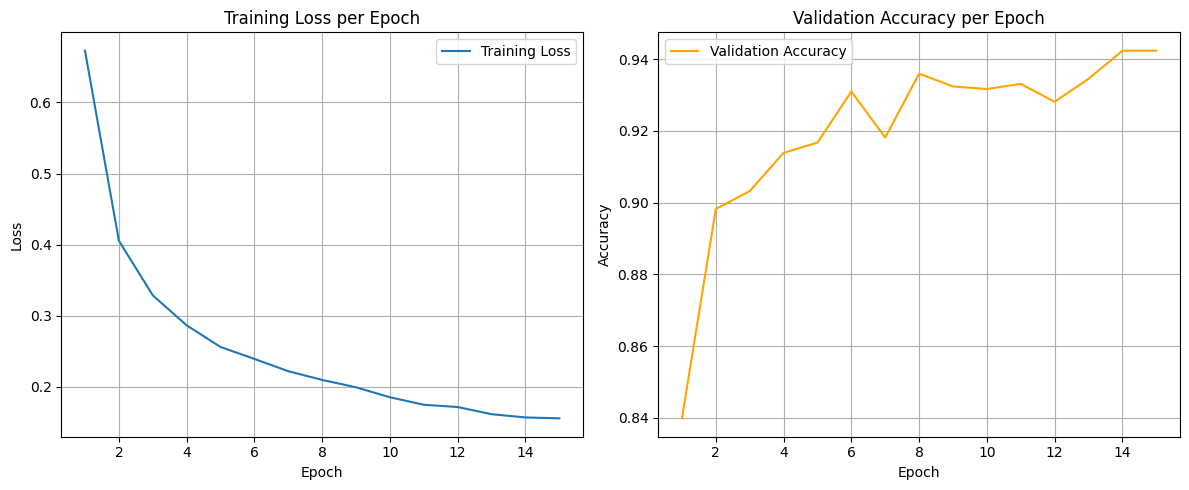

In [ ]:
epochs_range = range(1, len(vit_losses) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, vit_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, vit_val_accs, label='Validation Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy per Epoch')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

---
## Step 5 : Model Comparison and Final Evaluation



In this section, the performance of the trained SVM and fine-tuned ViT models are compared on the validation set. The model with the higher Micro F1 score is selected as the 'best model' and then evaluated on the unseen test dataset.

In [ ]:
import torch.nn.functional as F

# Print validation performance comparison
print("Validation Performance Comparison:")
print("-----------------------------------")
print(f"SVM Model:")
print(f"  Validation Micro F1: {best_val_f1:.4f}")

vit_final_val_f1 = vit_val_f1s_micro[-1]
print(f"\nViT Model:")
print(f"  Validation Micro F1: {vit_final_val_f1:.4f}")

print("\nSelecting the best model based on Validation Micro F1 Score...")

# Determine the best model based on validation F1 score
if best_val_f1 >= vit_final_val_f1:
    print("SVM model performed better on validation (Micro F1).")
    selected_model_name = "SVM"

    # Evaluate SVM on test set
    y_pred_test_svm = best_model.predict(X_test_scaled)
    final_test_accuracy = accuracy_score(y_test, y_pred_test_svm)
    final_test_f1 = f1_score(y_test, y_pred_test_svm, average='micro')

else:
    print("ViT model performed better on validation (Micro F1).")
    selected_model_name = "ViT"

    # Evaluate ViT on test set
    vit_model.eval()
    all_labels_vit_test = []
    all_preds_vit_test = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    vit_model.to(device)

    with torch.no_grad():
        for batch in vit_test_loader:
            images = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)
            logits = vit_model(pixel_values=images).logits
            preds = logits.argmax(1)
            all_labels_vit_test.extend(labels.cpu().numpy())
            all_preds_vit_test.extend(preds.cpu().numpy())

    final_test_accuracy = accuracy_score(all_labels_vit_test, all_preds_vit_test)
    final_test_f1 = f1_score(all_labels_vit_test, all_preds_vit_test, average='micro')

print("\nTest Performance of the Best Model:")
print("-------------------------------------")
print(f"Selected Model: {selected_model_name}")
print(f"Test Accuracy: {final_test_accuracy*100:.2f}%")
print(f"Test Micro F1: {final_test_f1:.4f}")

Validation Performance Comparison:
-----------------------------------
SVM Model:
  Validation Micro F1: 0.9416

ViT Model:
  Validation Micro F1: 0.9423

Selecting the best model based on Validation Micro F1 Score...
ViT model performed better on validation (Micro F1).

Test Performance of the Best Model:
-------------------------------------
Selected Model: ViT
Test Accuracy: 93.31%
Test Micro F1: 0.9331


---
## Step 6: Confusion Matrix and AUC-ROC for the Best Model


Finally, the performance of the selected best model on the test dataset is comprehensively evaluated using a Confusion Matrix and AUC-ROC curves to understand its classification capabilities and identify potential areas for improvement.


Generating Confusion Matrix for the ViT model...


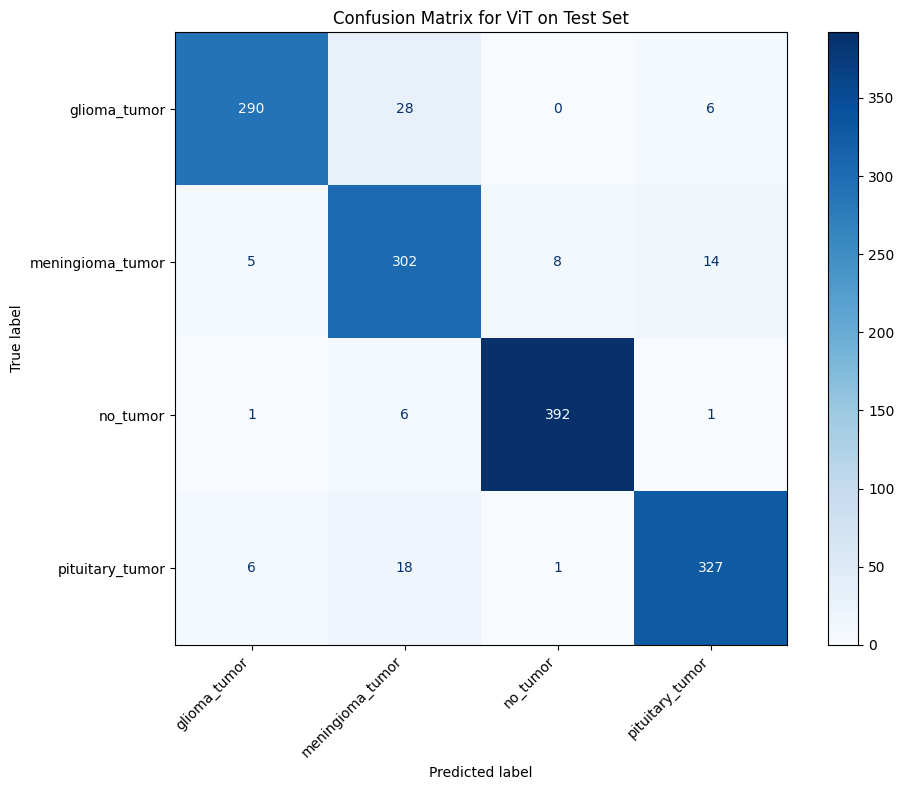


Generating AUC-ROC Curves for the ViT model...


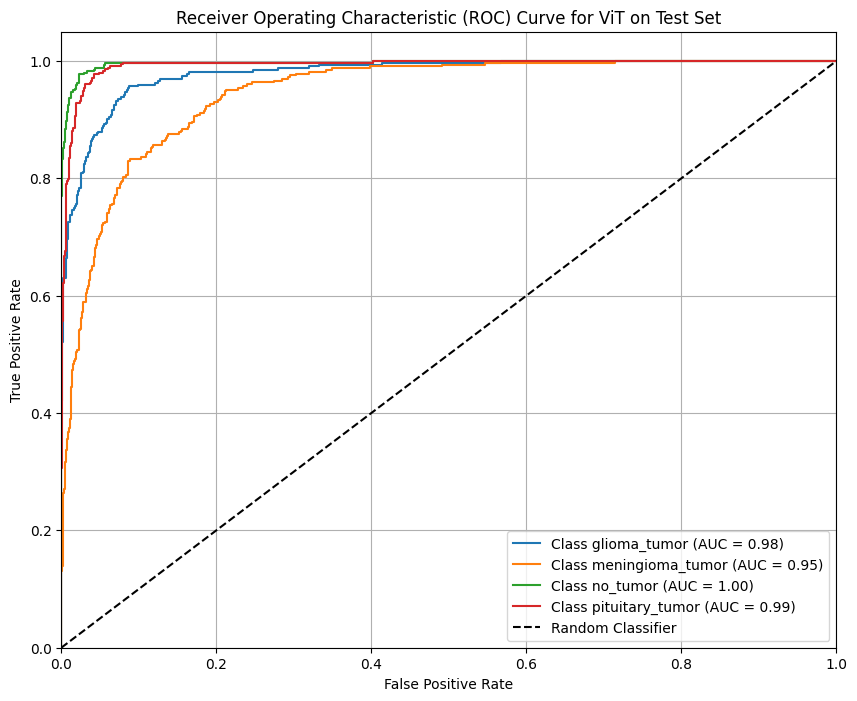

In [ ]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# --- Confusion Matrix ---
print(f"\nGenerating Confusion Matrix for the {selected_model_name} model...")

if selected_model_name == "SVM":
    y_true_cm = y_test
    y_pred_cm = y_pred_test_svm
    y_score_roc = best_model.decision_function(X_test_scaled)
else: # ViT model
    y_true_cm = all_labels_vit_test
    y_pred_cm = all_preds_vit_test

    # Re-run ViT inference on test set to get logits for ROC curve
    vit_model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    vit_model.to(device)

    all_logits_vit_test = []
    with torch.no_grad():
        for batch in vit_test_loader:
            images = batch["pixel_values"].to(device)
            logits = vit_model(pixel_values=images).logits
            all_logits_vit_test.extend(logits.cpu().numpy())
    y_score_roc = np.array(all_logits_vit_test)


cm = confusion_matrix(y_true_cm, y_pred_cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)

plt.figure(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=plt.gca())
plt.title(f'Confusion Matrix for {selected_model_name} on Test Set')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- AUC-ROC Curve ---
print(f"\nGenerating AUC-ROC Curves for the {selected_model_name} model...")

# Binarize the true labels for multi-class ROC
label_binarizer = LabelBinarizer()
y_true_binarized = label_binarizer.fit_transform(y_true_cm)

plt.figure(figsize=(10, 8))
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_score_roc[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {CLASS_NAMES[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC) Curve for {selected_model_name} on Test Set')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
